# ShopSphere — CLV (BG/NBD + Gamma-Gamma) & churn model (M5)

Two questions: **what is each customer worth going forward** (probabilistic CLV)
and **who is about to leave** (supervised churn). Both are fitted on the MySQL
gold layer and validated against held-out time — no random train/test on the
CLV side, a strict time cutoff on the churn side, so nothing leaks.

Models implemented in `python/04_model/btyd.py` (pure numpy/scipy, 8 unit
tests incl. parameter recovery). Time unit: weeks. Monetary = mean value of
REPEAT transactions (Gamma-Gamma convention). No discounting on the 12-month
CLV horizon (stated simplification).

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'data').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
sys.path.insert(0, str(ROOT / 'python' / '04_model'))
from config.db import get_engine
import btyd

FIG = ROOT / 'reports' / 'figures'
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GRAY = '#1f77b4', '#d62728', '#7f7f7f'

engine = get_engine()
tx = pd.read_sql(
    "SELECT r.customer_id, r.order_ts, r.order_revenue, s.acquisition_channel "
    "FROM gold_order_revenue r JOIN gold_customer_summary s "
    "ON s.customer_id = r.customer_id "
    "WHERE r.order_status = 'completed' AND r.order_revenue IS NOT NULL",
    engine, parse_dates=['order_ts'])
END = tx['order_ts'].max()
print(f'{len(tx):,} completed transactions, {tx.customer_id.nunique():,} buyers, '
      f'span {tx.order_ts.min():%Y-%m-%d} .. {END:%Y-%m-%d}')

17,719 completed transactions, 11,277 buyers, span 2024-06-07 .. 2026-06-30


In [2]:
def btyd_summary(df, end):
    """Per-customer BTYD summary in weeks at observation end `end`."""
    df = df[df['order_ts'] <= end]
    g = df.groupby('customer_id')['order_ts'].agg(['min', 'max', 'count'])
    out = pd.DataFrame({
        'x': g['count'] - 1.0,
        't_x': (g['max'] - g['min']).dt.total_seconds() / 86400 / 7,
        'T': (end - g['min']).dt.total_seconds() / 86400 / 7,
    })
    # repeat-transaction mean value (exclude each customer's first purchase)
    first = g['min'].rename('first_ts')
    rep = df.join(first, on='customer_id')
    rep = rep[rep['order_ts'] > rep['first_ts']]
    out['m_x'] = rep.groupby('customer_id')['order_revenue'].mean()
    return out[out['T'] > 0]

summary_full = btyd_summary(tx, END)
print(f'{len(summary_full):,} customers in full-window summary, '
      f'repeat buyers {(summary_full.x > 0).mean():.1%}')

11,276 customers in full-window summary, repeat buyers 29.6%


## Backtest first: does BG/NBD predict held-out purchases?

Fit on everything up to a cutoff 26 weeks before the end of the data, then
compare predicted vs actual repeat purchases per customer in those 26 weeks.
Note the holdout contains the strong 2026 growth ramp (documented in P3), so
some aggregate under-prediction is expected and is reported, not hidden.

In [3]:
CUTOFF = END - pd.Timedelta(weeks=26)
HORIZON_W = (END - CUTOFF).total_seconds() / 86400 / 7

cal = btyd_summary(tx, CUTOFF)
params_cal = btyd.fit_bgnbd(cal['x'], cal['t_x'], cal['T'])
pred = btyd.bgnbd_expected_purchases(params_cal, cal['x'], cal['t_x'],
                                     cal['T'], HORIZON_W)
hold = tx[tx['order_ts'] > CUTOFF]
actual = (hold[hold['customer_id'].isin(cal.index)]
          .groupby('customer_id').size().reindex(cal.index, fill_value=0))

ratio = pred.sum() / actual.sum()
corr = np.corrcoef(pred, actual)[0, 1]
print('calibration params', {k: round(v, 3) for k, v in params_cal.items()})
print(f'holdout {HORIZON_W:.0f}w: predicted {pred.sum():,.0f} vs actual '
      f'{actual.sum():,} repeat purchases (pred/actual {ratio:.2f}), '
      f'per-customer corr {corr:.3f}')

calibration params {'r': np.float64(0.101), 'alpha': np.float64(0.876), 'a': np.float64(11.406), 'b': np.float64(14.801)}
holdout 26w: predicted 1,180 vs actual 1,110 repeat purchases (pred/actual 1.06), per-customer corr 0.357


In [4]:
params = btyd.fit_bgnbd(summary_full['x'], summary_full['t_x'], summary_full['T'])
buyers_rep = summary_full[summary_full.x > 0]
gg_params = btyd.fit_gg(buyers_rep['x'], buyers_rep['m_x'])
prior_mean = gg_params['p'] * gg_params['gamma'] / (gg_params['q'] - 1)
xm_corr = np.corrcoef(buyers_rep['x'], buyers_rep['m_x'])[0, 1]

p_alive = btyd.bgnbd_p_alive(params, summary_full['x'], summary_full['t_x'],
                             summary_full['T'])
exp_purch_52 = btyd.bgnbd_expected_purchases(
    params, summary_full['x'], summary_full['t_x'], summary_full['T'], 52.0)
exp_value = np.where(
    summary_full['x'] > 0,
    btyd.gg_expected_value(gg_params, summary_full['x'].clip(lower=1),
                           summary_full['m_x'].fillna(prior_mean)),
    prior_mean)
clv12 = exp_purch_52 * exp_value
summary_full = summary_full.assign(p_alive=p_alive, clv12=clv12)

print('BG/NBD', {k: round(v, 3) for k, v in params.items()})
print('Gamma-Gamma', {k: round(v, 3) for k, v in gg_params.items()},
      f'| prior mean ${prior_mean:.2f} | corr(x, m_x) = {xm_corr:.3f}')
print(f'12-mo CLV: mean ${clv12.mean():.2f}, median ${np.median(clv12):.2f}, '
      f'total ${clv12.sum():,.0f}')
dec = summary_full.sort_values('clv12', ascending=False)
top_decile_share = dec['clv12'].head(len(dec) // 10).sum() / dec['clv12'].sum()
print(f'top decile holds {top_decile_share:.1%} of predicted 12-mo CLV')

BG/NBD {'r': np.float64(0.107), 'alpha': np.float64(0.922), 'a': np.float64(14.13), 'b': np.float64(21.339)}
Gamma-Gamma {'p': np.float64(1.428), 'q': np.float64(6.902), 'gamma': np.float64(386.632)} | prior mean $93.53 | corr(x, m_x) = 0.001
12-mo CLV: mean $25.09, median $13.42, total $282,875
top decile holds 38.2% of predicted 12-mo CLV


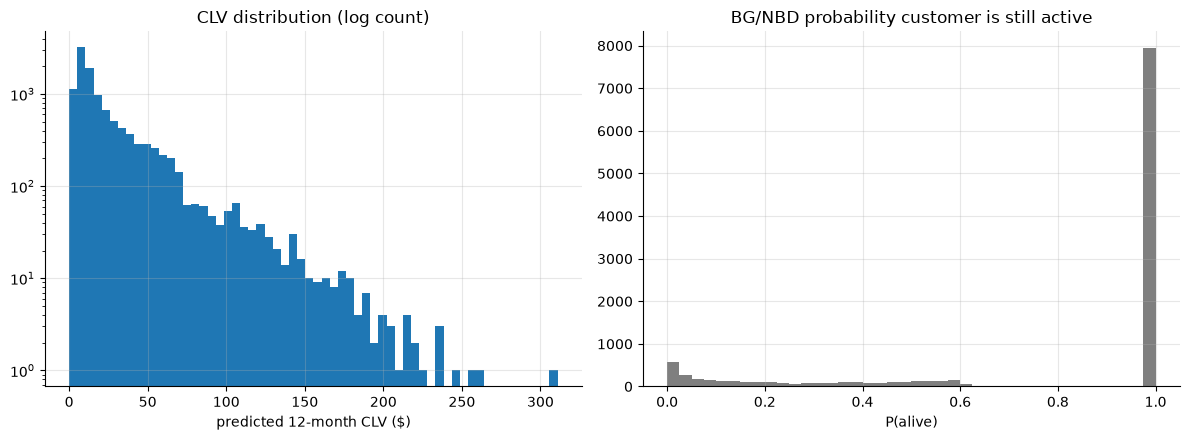

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].hist(summary_full['clv12'], bins=60, color=BLUE)
ax[0].set_yscale('log')
ax[0].set_xlabel('predicted 12-month CLV ($)')
ax[0].set_title('CLV distribution (log count)')
ax[1].hist(summary_full['p_alive'], bins=40, color=GRAY)
ax[1].set_xlabel('P(alive)')
ax[1].set_title('BG/NBD probability customer is still active')
fig.tight_layout()
fig.savefig(FIG / 'clv_distribution.png', bbox_inches='tight')
plt.show()

## Churn model

Definition: population = buyers with ≥1 completed order before the cutoff;
**churned = zero completed orders in the 26-week holdout**. All features are
computed strictly from pre-cutoff data (incl. the calibration-fit BG/NBD
P(alive) — fitted pre-cutoff, so no leakage). 75/25 stratified split,
`random_state=42` everywhere.

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

feat = cal.copy()
feat['recency_w'] = feat['T'] - feat['t_x']
feat['avg_gap_w'] = np.where(feat['x'] > 0, feat['t_x'] / feat['x'], np.nan)
feat['p_alive_cal'] = btyd.bgnbd_p_alive(params_cal, feat['x'], feat['t_x'], feat['T'])
mon = (tx[tx['order_ts'] <= CUTOFF].groupby('customer_id')['order_revenue']
       .agg(['sum', 'mean']))
feat[['rev_total', 'rev_mean']] = mon
chan = tx.drop_duplicates('customer_id').set_index('customer_id')['acquisition_channel']
feat = feat.join(pd.get_dummies(chan, prefix='ch').astype(float))
feat['churned'] = (~feat.index.isin(
    hold[hold['order_ts'] > CUTOFF]['customer_id'])).astype(int)

FEATURES = [c for c in feat.columns if c not in ('churned', 'm_x')]
X, y = feat[FEATURES], feat['churned']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          stratify=y, random_state=42)

gb = HistGradientBoostingClassifier(random_state=42).fit(X_tr, y_tr)
lr = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                   LogisticRegression(max_iter=2000)).fit(X_tr, y_tr)
p_gb = gb.predict_proba(X_te)[:, 1]
p_lr = lr.predict_proba(X_te)[:, 1]
auc_gb, auc_lr = roc_auc_score(y_te, p_gb), roc_auc_score(y_te, p_lr)
print(f'churn base rate {y.mean():.1%} | n={len(y):,} '
      f'(train {len(y_tr):,} / test {len(y_te):,})')
print(f'ROC-AUC: gradient boosting {auc_gb:.3f} | logistic {auc_lr:.3f}')

churn base rate 89.9% | n=6,712 (train 5,034 / test 1,678)
ROC-AUC: gradient boosting 0.793 | logistic 0.813


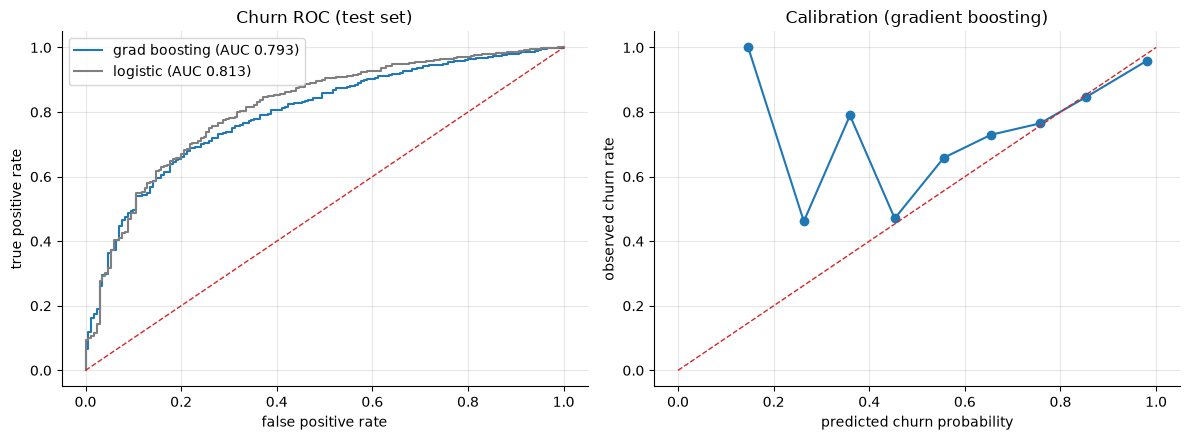

In [7]:
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for p, label, color in [(p_gb, f'grad boosting (AUC {auc_gb:.3f})', BLUE),
                        (p_lr, f'logistic (AUC {auc_lr:.3f})', GRAY)]:
    fpr, tpr, _ = roc_curve(y_te, p)
    ax[0].plot(fpr, tpr, color=color, label=label)
ax[0].plot([0, 1], [0, 1], ls='--', color=RED, lw=1)
ax[0].set_xlabel('false positive rate'); ax[0].set_ylabel('true positive rate')
ax[0].set_title('Churn ROC (test set)'); ax[0].legend()

frac_pos, mean_pred = calibration_curve(y_te, p_gb, n_bins=10)
ax[1].plot(mean_pred, frac_pos, marker='o', color=BLUE)
ax[1].plot([0, 1], [0, 1], ls='--', color=RED, lw=1)
ax[1].set_xlabel('predicted churn probability')
ax[1].set_ylabel('observed churn rate')
ax[1].set_title('Calibration (gradient boosting)')
fig.tight_layout()
fig.savefig(FIG / 'churn_roc_calibration.png', bbox_inches='tight')
plt.show()

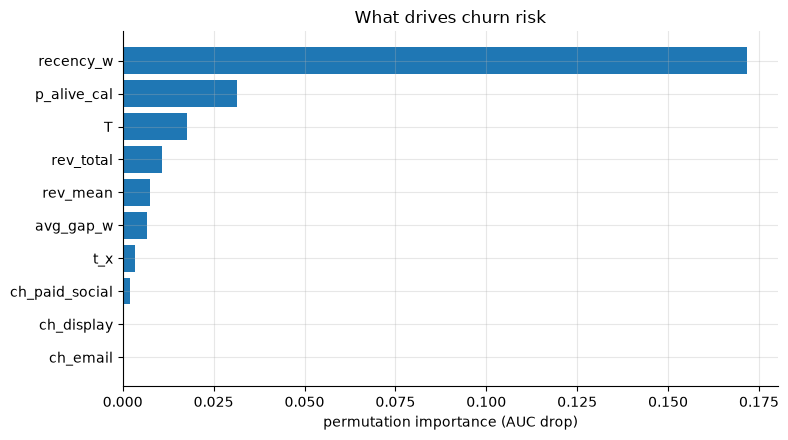

In [8]:
imp = permutation_importance(gb, X_te, y_te, scoring='roc_auc',
                             n_repeats=5, random_state=42)
order = np.argsort(imp.importances_mean)[-10:]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(np.array(FEATURES)[order], imp.importances_mean[order], color=BLUE)
ax.set_xlabel('permutation importance (AUC drop)')
ax.set_title('What drives churn risk')
fig.tight_layout()
fig.savefig(FIG / 'churn_feature_importance.png', bbox_inches='tight')
plt.show()

## Validation — ties to gold + hard sanity gates

Fails on execution if the warehouse numbers drift or a model degenerates.

In [9]:
from sqlalchemy import text

with engine.connect() as conn:
    gold_rev = float(conn.execute(text(
        'SELECT SUM(revenue) FROM gold_monthly_kpis')).scalar_one())
    pareto_buyers = conn.execute(text(
        'SELECT MAX(buyer_count) FROM gold_customer_pareto')).scalar_one()
    zero_rev_buyers = conn.execute(text(
        'SELECT COUNT(*) FROM gold_customer_summary '
        'WHERE orders_completed > 0 AND revenue_completed = 0')).scalar_one()

assert abs(tx['order_revenue'].sum() - gold_rev) < 0.01
# buyers absent here must be exactly those whose completed orders all lost
# their items in cleaning (revenue_completed = 0 in gold)
assert pareto_buyers - tx['customer_id'].nunique() == zero_rev_buyers, (
    'buyer count drifted vs gold_customer_pareto')
assert auc_gb > 0.6 and auc_lr > 0.6, 'churn model degenerated'
assert 0.5 < ratio < 1.5, 'BG/NBD backtest ratio out of range'
assert (clv12 >= 0).all()

print(f"revenue loaded          ${tx['order_revenue'].sum():,.2f} (= gold)")
print(f"buyers with revenue     {tx['customer_id'].nunique():,} "
      f"(gold pareto {pareto_buyers:,}; diff {zero_rev_buyers} = buyers whose "
      f"completed orders lost all items in cleaning)")
print(f"backtest pred/actual    {ratio:.2f} | corr {corr:.3f}")
print(f"12-mo CLV total         ${clv12.sum():,.0f} | top decile {top_decile_share:.1%}")
print(f"churn AUC               gb {auc_gb:.3f} / lr {auc_lr:.3f} "
      f"| base rate {y.mean():.1%}")
print('figures ->', sorted(p.name for p in FIG.glob('c*.png')))

revenue loaded          $1,664,813.13 (= gold)
buyers with revenue     11,277 (gold pareto 11,323; diff 46 = buyers whose completed orders lost all items in cleaning)
backtest pred/actual    1.06 | corr 0.357
12-mo CLV total         $282,875 | top decile 38.2%
churn AUC               gb 0.793 / lr 0.813 | base rate 89.9%
figures -> ['cac_by_channel.png', 'churn_feature_importance.png', 'churn_roc_calibration.png', 'clv_distribution.png', 'customer_pareto.png']
